In [ ]:
import pandas as pd
import numpy as np
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

data_path = (
    r"C:\Users\bashi\Azercell & AWS Bootcamp\PW\data\data_usage_production_sample.csv"
)
df = pd.read_csv(data_path, index_col=0)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 3463985 to 2093924
Data columns (total 69 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   telephone_number              1000000 non-null  object 
 1   tariff_desc                   1000000 non-null  object 
 2   customer_status               1000000 non-null  object 
 3   tenure                        1000000 non-null  int64  
 4   data_compl_usg_local_m2       1000000 non-null  float64
 5   data_amount_lte_m2            1000000 non-null  float64
 6   data_pack_usg_m2              1000000 non-null  float64
 7   dpi_https_and_default_m2      1000000 non-null  float64
 8   data_pack_rev_local_m2        1000000 non-null  float64
 9   refill_total_m2               1000000 non-null  float64
 10  dpi_tik_tok_m2                1000000 non-null  float64
 11  dpi_youtube_m2                1000000 non-null  float64
 12  dpi_instagram_m2           

In [3]:
df.isnull().sum().sum()

0

In [4]:
df["data_compl_usg_local_m1"].sample(5)

4102404       25.96
3126605        0.00
5056615      825.13
1234768    14753.02
1335075        0.00
Name: data_compl_usg_local_m1, dtype: float64

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:10]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Set telephone_number as index
df.set_index("telephone_number", inplace=True)
print(f"\nAfter setting index, shape: {df.shape}")
print(f"Index is now: {df.index.name}")

Numeric columns (61): ['tenure', 'data_compl_usg_local_m2', 'data_amount_lte_m2', 'data_pack_usg_m2', 'dpi_https_and_default_m2', 'data_pack_rev_local_m2', 'refill_total_m2', 'dpi_tik_tok_m2', 'dpi_youtube_m2', 'dpi_instagram_m2']...
Categorical columns (8): ['telephone_number', 'tariff_desc', 'customer_status', 'lasttariff_m2', 'lasttariff_m3', 'lasttariff_m4', 'lasttariff_m5', 'lasttariff_m6']

After setting index, shape: (1000000, 68)
Index is now: telephone_number


In [6]:
# Prepare features and target
X = df.drop(["data_compl_usg_local_m1"], axis=1)
y = df["data_compl_usg_local_m1"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features (excluding target):", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"\nTrain set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set shape: X_test {X_test.shape}, y_test {y_test.shape}")

Features shape: (1000000, 67)
Target shape: (1000000,)
Number of features (excluding target): 67

Train set shape: X_train (800000, 67), y_train (800000,)
Test set shape: X_test (200000, 67), y_test (200000,)


In [7]:
# Get numeric and categorical features from training data
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):")
print(numeric_features[:10] if len(numeric_features) > 10 else numeric_features)
print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

# Analyze cardinality of categorical columns
print("\n=== Categorical Column Cardinality Analysis ===")
for col in categorical_features:
    unique_count = X[col].nunique()
    sample_values = X[col].value_counts().head(5)
    print(f"\n{col}:")
    print(f"  Unique values: {unique_count:,}")
    print(f"  Top 5 values:")
    for val, count in sample_values.items():
        percentage = (count / len(X)) * 100
        print(f"    '{val}': {count:,} ({percentage:.2f}%)")

# Define high cardinality threshold (>10 unique values for this dataset)
high_cardinality_threshold = 10
high_cardinality_cols = []
low_cardinality_cols = []

for col in categorical_features:
    if X[col].nunique() > high_cardinality_threshold:
        high_cardinality_cols.append(col)
    else:
        low_cardinality_cols.append(col)

print(f"\n=== Cardinality Classification ===")
print(
    f"High cardinality columns (>{high_cardinality_threshold} unique values): {high_cardinality_cols}"
)
print(
    f"Low cardinality columns (≤{high_cardinality_threshold} unique values): {low_cardinality_cols}"
)

Numeric features (60):
['tenure', 'data_compl_usg_local_m2', 'data_amount_lte_m2', 'data_pack_usg_m2', 'dpi_https_and_default_m2', 'data_pack_rev_local_m2', 'refill_total_m2', 'dpi_tik_tok_m2', 'dpi_youtube_m2', 'dpi_instagram_m2']

Categorical features (7):
['tariff_desc', 'customer_status', 'lasttariff_m2', 'lasttariff_m3', 'lasttariff_m4', 'lasttariff_m5', 'lasttariff_m6']

=== Categorical Column Cardinality Analysis ===

tariff_desc:
  Unique values: 30
  Top 5 values:
    'Bolge': 360,545 (36.05%)
    'Azercellim': 219,978 (22.00%)
    'SuperSen 1GB': 73,483 (7.35%)
    'SuperSen 3GB': 45,610 (4.56%)
    'G6': 43,301 (4.33%)

customer_status:
  Unique values: 2
  Top 5 values:
    'Active': 564,328 (56.43%)
    'Suspended': 435,672 (43.57%)

lasttariff_m2:
  Unique values: 41
  Top 5 values:
    'Bolge': 361,624 (36.16%)
    'Azercellim': 221,677 (22.17%)
    'SuperSen 1GB': 74,063 (7.41%)
    'SuperSen 3GB': 43,999 (4.40%)
    'G6': 43,066 (4.31%)

lasttariff_m3:
  Unique values:

In [8]:
# Create column transformer with CatBoost encoder for high cardinality columns
print("=== Creating Column Transformer with CatBoost Encoder ===")

# Numeric features pipeline
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Low cardinality categorical features pipeline (use OneHotEncoder)
low_cardinality_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

# High cardinality categorical features pipeline (use CatBoostEncoder)
high_cardinality_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        (
            "catboost_encoder",
            CatBoostEncoder(
                return_df=False,  # Return numpy array instead of DataFrame
                handle_unknown="return_nan",  # Handle unknown categories
                random_state=42,  # For reproducibility
            ),
        ),
    ]
)

# Create ColumnTransformer with separate handling for high and low cardinality features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat_low", low_cardinality_transformer, low_cardinality_cols),
        ("cat_high", high_cardinality_transformer, high_cardinality_cols),
    ],
    remainder="drop",
)

print("✅ Column Transformer Created:")
print(
    f"   - Numeric features ({len(numeric_features)}): Median imputation + Standard scaling"
)
print(
    f"   - Low cardinality categorical ({len(low_cardinality_cols)}): OneHot encoding"
)
print(
    f"   - High cardinality categorical ({len(high_cardinality_cols)}): CatBoost encoding"
)
print(f"   - Low cardinality columns: {low_cardinality_cols}")
print(f"   - High cardinality columns: {high_cardinality_cols}")

# Create complete pipeline with CatBoost encoder
complete_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                n_jobs=-1,
            ),
        ),
    ]
)

print("✅ Complete Pipeline with CatBoost Encoder Created!")

=== Creating Column Transformer with CatBoost Encoder ===
✅ Column Transformer Created:
   - Numeric features (60): Median imputation + Standard scaling
   - Low cardinality categorical (1): OneHot encoding
   - High cardinality categorical (6): CatBoost encoding
   - Low cardinality columns: ['customer_status']
   - High cardinality columns: ['tariff_desc', 'lasttariff_m2', 'lasttariff_m3', 'lasttariff_m4', 'lasttariff_m5', 'lasttariff_m6']
✅ Complete Pipeline with CatBoost Encoder Created!


In [9]:
# Train model with CatBoost encoder
print("=== Training Model with CatBoost Encoder ===")

# Train the pipeline
print("Training pipeline with CatBoost encoder...")
complete_pipeline.fit(X_train, y_train)
print("✅ Pipeline training completed!")

# Make predictions
print("Making predictions...")
y_train_pred = complete_pipeline.predict(X_train)
y_test_pred = complete_pipeline.predict(X_test)

# Calculate evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n=== Model Performance Evaluation ===")
print(f"Training Set:")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R² Score: {train_r2:.4f}")
print()
print(f"Test Set:")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R² Score: {test_r2:.4f}")
print()

# Check for overfitting
if train_r2 - test_r2 > 0.1:
    print(
        "⚠️  Warning: Possible overfitting detected (training R² significantly higher than test R²)"
    )
else:
    print("✅ Model shows good generalization")

print(f"\nTarget variable statistics:")
print(f"  Mean: {y.mean():.4f}")
print(f"  Std: {y.std():.4f}")
print(f"  Min: {y.min():.4f}")
print(f"  Max: {y.max():.4f}")

print("✅ Model training and evaluation completed!")

=== Training Model with CatBoost Encoder ===
Training pipeline with CatBoost encoder...
✅ Pipeline training completed!
Making predictions...

=== Model Performance Evaluation ===
Training Set:
  MSE: 11997114.0831
  RMSE: 3463.6850
  R² Score: 0.7743

Test Set:
  MSE: 15505946.9942
  RMSE: 3937.7591
  R² Score: 0.7087

✅ Model shows good generalization

Target variable statistics:
  Mean: 1990.3890
  Std: 7291.6427
  Min: 0.0000
  Max: 538188.5400
✅ Model training and evaluation completed!


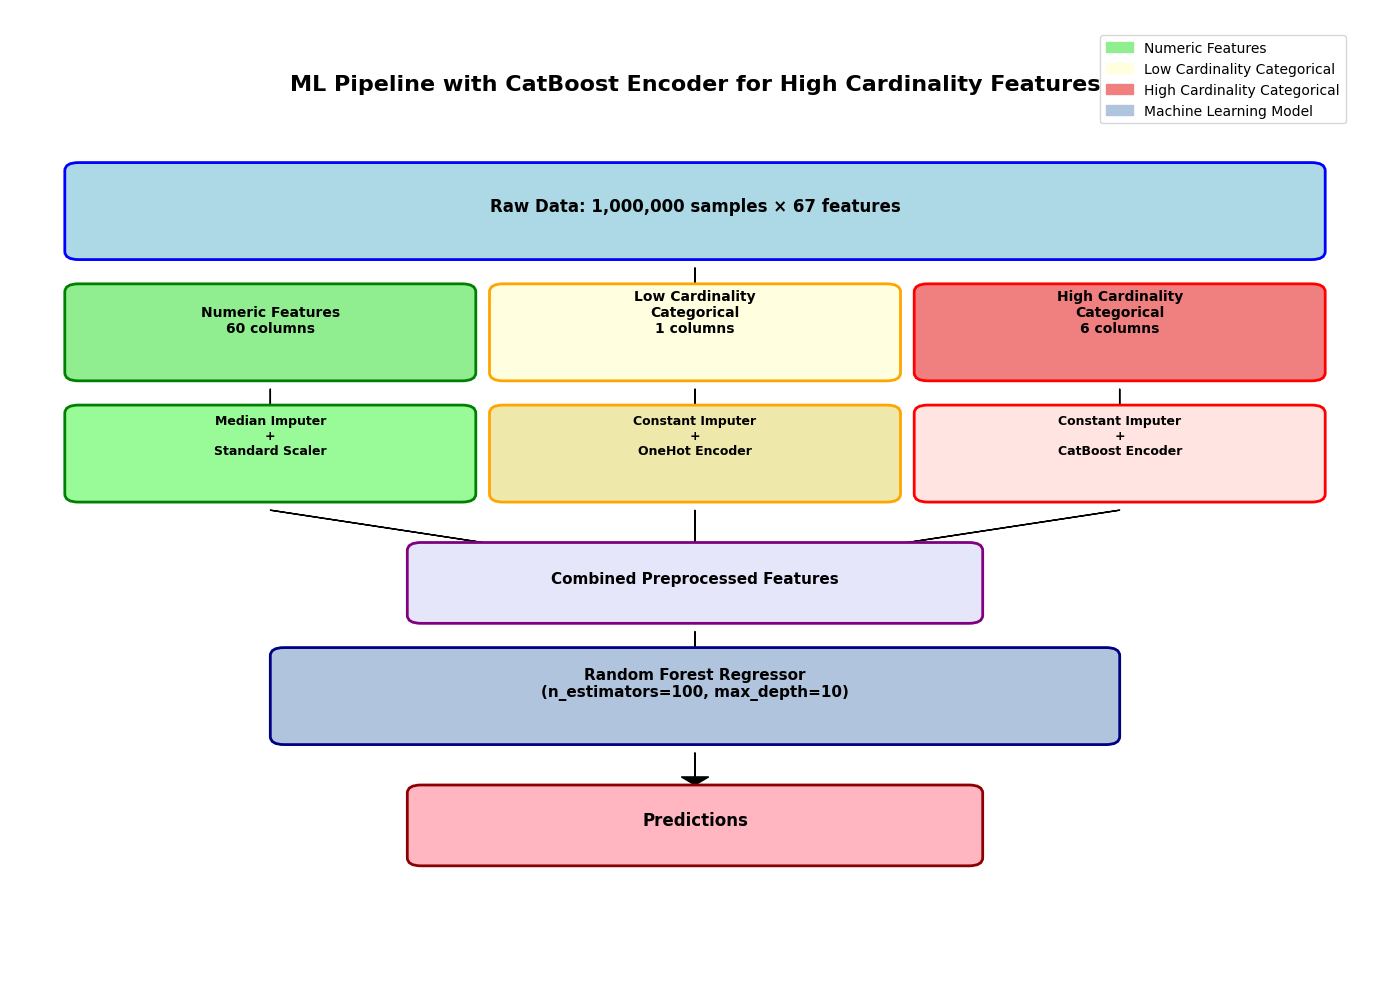

PIPELINE SUMMARY: CatBoost Encoder for High Cardinality Features

📊 FEATURE BREAKDOWN:
• Total features: 67
• Numeric features: 60
• Categorical features: 7
  - Low cardinality (≤10 unique): 1
  - High cardinality (>10 unique): 6

🔧 PREPROCESSING APPROACH:
• Numeric: Median imputation → Standard scaling
• Low cardinality categorical: Constant imputation → OneHot encoding
• High cardinality categorical: Constant imputation → CatBoost encoding

🎯 HIGH CARDINALITY COLUMNS:
• tariff_desc: 30 unique values
• lasttariff_m2: 41 unique values
• lasttariff_m3: 42 unique values
• lasttariff_m4: 42 unique values
• lasttariff_m5: 42 unique values
• lasttariff_m6: 42 unique values

✅ ADVANTAGES OF CATBOOST ENCODER:
• Handles high cardinality efficiently without sparse matrices
• Memory efficient - no explosion of dummy columns
• Target-based encoding with cross-validation protection
• Graceful handling of unknown categories


In [10]:
# Pipeline visualization and summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Create pipeline visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis("off")

# Title
ax.text(
    5,
    11,
    "ML Pipeline with CatBoost Encoder for High Cardinality Features",
    fontsize=16,
    fontweight="bold",
    ha="center",
)

# Input data box
input_box = FancyBboxPatch(
    (0.5, 9),
    9,
    1,
    boxstyle="round,pad=0.1",
    facecolor="lightblue",
    edgecolor="blue",
    linewidth=2,
)
ax.add_patch(input_box)
ax.text(
    5,
    9.5,
    f"Raw Data: {X.shape[0]:,} samples × {X.shape[1]} features",
    fontsize=12,
    ha="center",
    fontweight="bold",
)

# Arrow down
ax.arrow(5, 8.8, 0, -0.3, head_width=0.2, head_length=0.1, fc="black", ec="black")

# Feature types
feature_y = 7.5
# Numeric features
num_box = FancyBboxPatch(
    (0.5, feature_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="lightgreen",
    edgecolor="green",
    linewidth=2,
)
ax.add_patch(num_box)
ax.text(
    1.9,
    feature_y + 0.5,
    f"Numeric Features\n{len(numeric_features)} columns",
    fontsize=10,
    ha="center",
    fontweight="bold",
)

# Low cardinality categorical
low_box = FancyBboxPatch(
    (3.6, feature_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="lightyellow",
    edgecolor="orange",
    linewidth=2,
)
ax.add_patch(low_box)
ax.text(
    5,
    feature_y + 0.5,
    f"Low Cardinality\nCategorical\n{len(low_cardinality_cols)} columns",
    fontsize=10,
    ha="center",
    fontweight="bold",
)

# High cardinality categorical
high_box = FancyBboxPatch(
    (6.7, feature_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="lightcoral",
    edgecolor="red",
    linewidth=2,
)
ax.add_patch(high_box)
ax.text(
    8.1,
    feature_y + 0.5,
    f"High Cardinality\nCategorical\n{len(high_cardinality_cols)} columns",
    fontsize=10,
    ha="center",
    fontweight="bold",
)

# Arrows down
for x_pos in [1.9, 5, 8.1]:
    ax.arrow(
        x_pos, 7.3, 0, -0.3, head_width=0.15, head_length=0.1, fc="black", ec="black"
    )

# Preprocessing steps
preprocess_y = 6
# Numeric preprocessing
num_prep_box = FancyBboxPatch(
    (0.5, preprocess_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="palegreen",
    edgecolor="green",
    linewidth=2,
)
ax.add_patch(num_prep_box)
ax.text(
    1.9,
    preprocess_y + 0.5,
    "Median Imputer\n+\nStandard Scaler",
    fontsize=9,
    ha="center",
    fontweight="bold",
)

# Low cardinality preprocessing
low_prep_box = FancyBboxPatch(
    (3.6, preprocess_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="palegoldenrod",
    edgecolor="orange",
    linewidth=2,
)
ax.add_patch(low_prep_box)
ax.text(
    5,
    preprocess_y + 0.5,
    "Constant Imputer\n+\nOneHot Encoder",
    fontsize=9,
    ha="center",
    fontweight="bold",
)

# High cardinality preprocessing
high_prep_box = FancyBboxPatch(
    (6.7, preprocess_y),
    2.8,
    1,
    boxstyle="round,pad=0.1",
    facecolor="mistyrose",
    edgecolor="red",
    linewidth=2,
)
ax.add_patch(high_prep_box)
ax.text(
    8.1,
    preprocess_y + 0.5,
    "Constant Imputer\n+\nCatBoost Encoder",
    fontsize=9,
    ha="center",
    fontweight="bold",
)

# Arrows converging
for x_pos in [1.9, 5, 8.1]:
    ax.arrow(
        x_pos,
        5.8,
        5 - x_pos,
        -0.8,
        head_width=0.1,
        head_length=0.1,
        fc="black",
        ec="black",
    )

# Combined features
combined_box = FancyBboxPatch(
    (3, 4.5),
    4,
    0.8,
    boxstyle="round,pad=0.1",
    facecolor="lavender",
    edgecolor="purple",
    linewidth=2,
)
ax.add_patch(combined_box)
ax.text(
    5,
    4.9,
    "Combined Preprocessed Features",
    fontsize=11,
    ha="center",
    fontweight="bold",
)

# Arrow down
ax.arrow(5, 4.3, 0, -0.3, head_width=0.2, head_length=0.1, fc="black", ec="black")

# Model
model_box = FancyBboxPatch(
    (2, 3),
    6,
    1,
    boxstyle="round,pad=0.1",
    facecolor="lightsteelblue",
    edgecolor="navy",
    linewidth=2,
)
ax.add_patch(model_box)
ax.text(
    5,
    3.5,
    "Random Forest Regressor\n(n_estimators=100, max_depth=10)",
    fontsize=11,
    ha="center",
    fontweight="bold",
)

# Arrow down
ax.arrow(5, 2.8, 0, -0.3, head_width=0.2, head_length=0.1, fc="black", ec="black")

# Output
output_box = FancyBboxPatch(
    (3, 1.5),
    4,
    0.8,
    boxstyle="round,pad=0.1",
    facecolor="lightpink",
    edgecolor="darkred",
    linewidth=2,
)
ax.add_patch(output_box)
ax.text(5, 1.9, "Predictions", fontsize=12, ha="center", fontweight="bold")

# Add legend
legend_elements = [
    mpatches.Patch(color="lightgreen", label="Numeric Features"),
    mpatches.Patch(color="lightyellow", label="Low Cardinality Categorical"),
    mpatches.Patch(color="lightcoral", label="High Cardinality Categorical"),
    mpatches.Patch(color="lightsteelblue", label="Machine Learning Model"),
]
ax.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

# Print pipeline summary
print("=" * 80)
print("PIPELINE SUMMARY: CatBoost Encoder for High Cardinality Features")
print("=" * 80)

print(f"\n📊 FEATURE BREAKDOWN:")
print(f"• Total features: {len(numeric_features + categorical_features)}")
print(f"• Numeric features: {len(numeric_features)}")
print(f"• Categorical features: {len(categorical_features)}")
print(
    f"  - Low cardinality (≤{high_cardinality_threshold} unique): {len(low_cardinality_cols)}"
)
print(
    f"  - High cardinality (>{high_cardinality_threshold} unique): {len(high_cardinality_cols)}"
)

print(f"\n🔧 PREPROCESSING APPROACH:")
print(f"• Numeric: Median imputation → Standard scaling")
print(f"• Low cardinality categorical: Constant imputation → OneHot encoding")
print(f"• High cardinality categorical: Constant imputation → CatBoost encoding")

print(f"\n🎯 HIGH CARDINALITY COLUMNS:")
for col in high_cardinality_cols:
    print(f"• {col}: {X[col].nunique()} unique values")

print(f"\n✅ ADVANTAGES OF CATBOOST ENCODER:")
print(f"• Handles high cardinality efficiently without sparse matrices")
print(f"• Memory efficient - no explosion of dummy columns")
print(f"• Target-based encoding with cross-validation protection")
print(f"• Graceful handling of unknown categories")

print("=" * 80)

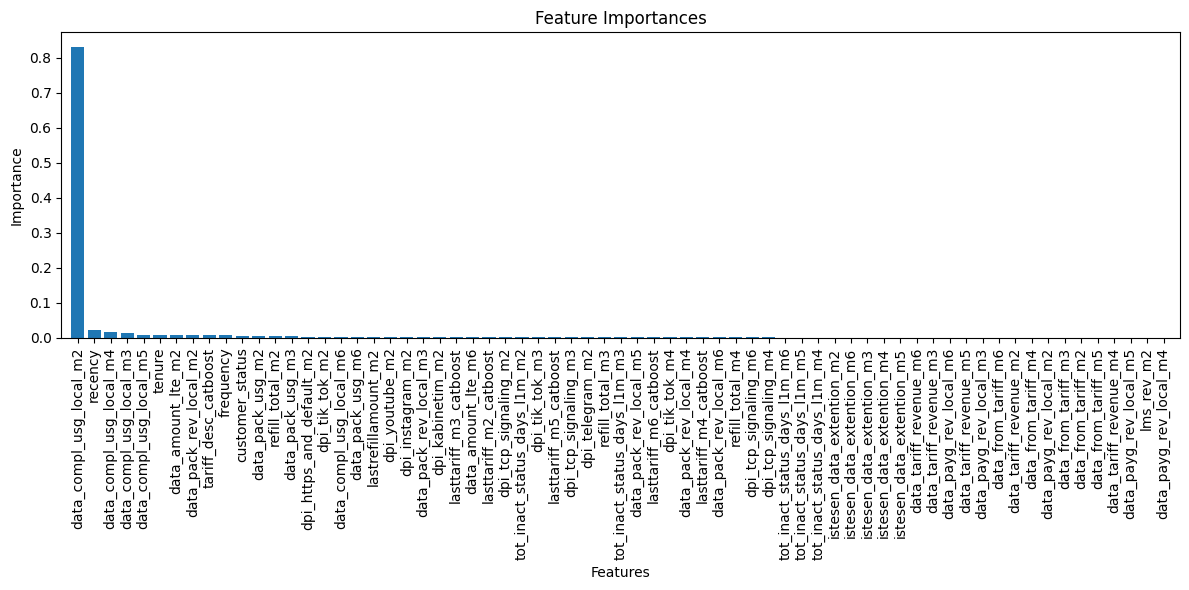

In [11]:
# feature importance
import matplotlib.pyplot as plt

importances = complete_pipeline.named_steps["regressor"].feature_importances_
feature_names = (
    numeric_features
    + low_cardinality_cols
    + [f"{col}_catboost" for col in high_cardinality_cols]
)
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")

plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [12]:
df.recency

telephone_number
s3h7KhSCIQ      1.0
0eOKwaabLs    131.0
mrP_AWLH3Z    150.0
J5ucLpi0RZ    150.0
8O3g6W0leB      0.0
              ...  
XlBkuPWgHT      0.0
kCqRCC8gwc    150.0
fvHnUgmyqO    150.0
AL7kqj_DxS    150.0
dweU4ZSIVS      0.0
Name: recency, Length: 1000000, dtype: float64